In [ ]:
!python3 -m pip install matplotlib google-cloud-bigquery pandas

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from google.cloud import bigquery
import pandas as pd


bq_client = bigquery.Client(project="ld-ds-genai-dev")

In [8]:
fixture_query_path = "process_floor_plan/queries/fixtures.sql"
store_id = "1011"


fixture_query  = f'''
WITH
  floor_plan AS (
  SELECT
    DBVERSIONKEY AS floor_plan_key,
    VALUE1 AS store_id,
  FROM
    `ds-bi-analytics-prod.JDA.JDA_IX_FLR_FLOORPLAN`
  WHERE
    VALUE1 = "{store_id}"
    AND DELETED_FLAG = FALSE
    AND STATUS1 = "Live"
    AND DBVERSIONKEY in (select DBPARENTFLOORPLANKEY from `ds-bi-analytics-prod.JDA.JDA_IX_FLR_FIXTURE`)
  ORDER BY
    timestamp DESC
  LIMIT
    1 ),
  fixture AS (
  SELECT
    floor_plan_key,
    store_id,
    SAFE_CAST(ANGLE AS INT64) AS ANGLE,
    SAFE_CAST(WIDTH AS INT64) AS WIDTH,
    SAFE_CAST(DEPTH AS INT64) AS DEPTH,
    SAFE_CAST(HEIGHT AS INT64) AS HEIGHT,
    SAFE_CAST(X AS FLOAT64) AS X,
    SAFE_CAST(Y AS FLOAT64) AS Y,
    SAFE_CAST(Z AS FLOAT64) AS Z,
    DESC5 AS AISLE,
    DESC9 AS PCX_LOCATION,
    TYPE AS FIXTURE_TYPE,
  FROM
    floor_plan
  LEFT JOIN
    `ds-bi-analytics-prod.JDA.JDA_IX_FLR_FIXTURE` fixt
  ON
    fixt.DBPARENTFLOORPLANKEY = floor_plan.floor_plan_key
  WHERE
    DELETED_FLAG = FALSE
  AND
    TYPE in ("0", "1")) -- type 0 is for regular fixtures, and type 1 for irregular ones

SELECT
  floor_plan_key,
  store_id,
  X AS STARTING_X,
  case
    when fixture.ANGLE in (270,90) then COS(-1*fixture.Angle*0.01745329251)*fixture.WIDTH + SIN(-1*fixture.Angle*0.01745329251)*fixture.DEPTH +fixture.X
    else COS(fixture.Angle*0.01745329251)*fixture.WIDTH + SIN(fixture.Angle*0.01745329251)*fixture.DEPTH + fixture.X
  end AS ENDING_X,
  Y AS STARTING_Y,
  (SIN(fixture.Angle*0.01745329251)*fixture.WIDTH + COS(fixture.Angle*0.01745329251)*fixture.DEPTH + fixture.Y) AS ENDING_Y,
  Z,
  WIDTH,
  DEPTH,
  HEIGHT,
  ANGLE,
  AISLE,
  PCX_LOCATION,
  FIXTURE_TYPE,
FROM
  fixture
'''
fixtures_df = bq_client.query(fixture_query).to_dataframe()

fixtures_df

,floor_plan_key,store_id,STARTING_X,ENDING_X,STARTING_Y,ENDING_Y,Z,WIDTH,DEPTH,HEIGHT,ANGLE,AISLE,PCX_LOCATION,FIXTURE_TYPE,FORBIDDEN_FLAG
0,208376,1011,2356.963846,2360.963846,2091.026196,2082.026196,0.2,9.0,4.0,2,270,JO01C,None,0,1
1,208376,1011,2323.517028,2294.517028,2548.190884,2529.190884,0.2,29.0,19.0,2,180,JO01C,None,0,1
2,208376,1011,2298.397436,2317.397436,1944.551934,1915.551934,0.2,29.0,19.0,2,270,JO01C,None,0,1
3,208376,1011,568.863276,580.863276,2029.405762,1981.405762,0.2,48.0,12.0,2,270,DL01L,None,0,0
4,208376,1011,2189.842344,2177.842344,1692.227812,1740.227813,0.2,48.0,12.0,2,90,JO01C,None,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1608,208376,1011,2818.020020,2787.020020,2100.650391,2148.650391,0.2,48.0,31.0,2,90,GR03L,None,0,0
1609,208376,1011,2818.020020,2787.020020,2532.650391,2580.650391,0.2,48.0,31.0,2,90,GR03L,None,0,0
1610,208376,1011,2818.020020,2787.020020,1476.650391,1524.650391,0.2,48.0,31.0,2,90,GR03L,None,0,0
1611,208376,1011,2818.020020,2787.020020,2292.650391,2340.650391,0.2,48.0,31.0,2,90,GR03L,None,0,0


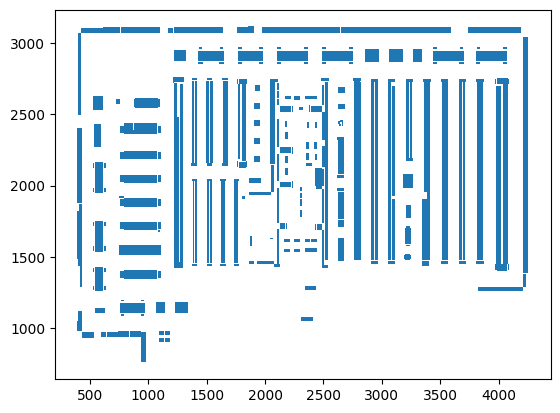

In [16]:
fig, ax = plt.subplots()
ax.plot()
for x, y, x1, y1 in zip(fixtures_df["STARTING_X"], fixtures_df["STARTING_Y"], fixtures_df["ENDING_X"], fixtures_df["ENDING_Y"]):
    ax.add_patch(Rectangle((x, y), float(x1-x), float(y1-y)))

plt.show()

In [9]:
item_fixture_query  = f'''
SELECT
  *,
  STARTING_X_FT*12 AS X1,
  STARTING_Y_FT*12 AS Y1
FROM
  `ds-bi-analytics-prod.JDA.JDA_ITEM_LOCATION` jda
JOIN (
  SELECT
    liam, nav_categories
  FROM
    `ds-bi-analytics-prod.product_catalog.products`
  WHERE
    status="APPROVED")pcs
ON
  jda.ARTICLE_ID_UOM = pcs.liam
WHERE
    STORE_ID = "{store_id}"
'''
item_fixtures_df = bq_client.query(item_fixture_query).to_dataframe()

item_fixtures_df

,STORE_ID,SPC_PLANOGRAM_NAME,PRODUCT_NAME,ARTICLE_ID_UOM,UPC,WEIGHT,COORD_X_INCH,COORD_Y_INCH,HEIGHT,WIDTH,...,FLR_FIXTURE_NAME,LOCATION,STAGING_X,STAGING_Y,X,Y,liam,nav_categories,X1,Y1
0,1011,HEARING_AID_BATTERIES_02X14_RACK,ENERGIZER WATCH 2025 2,20002268002_EA,039800032836,.0080000000000000002,20.125,5.8700000000000001,3.75,1.75,...,PP_21x54x8,170.512916667,317.650000000,62.780000000,170.512916667,135.890000000,20002268002_EA,"[{'code': 28011, 'en': 'Household Supplies', '...",2066.280000000,1630.680000000
1,1011,PACKAGED_SALADS_06X36_MARKET_ONTARIO,SF PAD THAI SALAD 300G,20249840_EA,773200712409,.318,16.489999999999998,25.5,2.7999999999999998,5.4699999999999998,...,DTBunker_72xHx36 - 20,96.795833333,317.650000000,62.780000000,63.170000000,96.795833333,20249840_EA,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",758.040000000,1178.040000000
2,1011,COMMERCIAL_BREAD_FLATBREAD_22X78_WALKAROUND_MA...,FRONTIER PITA POUCH WW,21182503_EA,628242840231,.43099999999999999,142.85000610351562,53,8.4499999999999993,8.4499999999999993,...,BakeryTable_108xHx60 - 4,59.304167175,317.650000000,62.780000000,59.304167175,244.130000000,21182503_EA,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",568.800000000,2929.560000000
3,1011,FRESH_SEAFOOD_04X36_MARKET_ONTARIO,SARDO MARINATED SEAFOOD SALAD,20921347_EA,055823081804,.57999999999999996,29.699999999999996,20.5,3.4500000000000002,4.6500000000000004,...,MTOpenAir_96x73x43 - 43,148.785000000,317.650000000,62.780000000,148.785000000,255.850000000,20921347_EA,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",1755.720000000,3070.200000000
4,1011,COMMERCIAL_BREAD_FLATBREAD_22X78_WALKAROUND_MA...,PC OLD WORLD PITA,21431960_EA,060383046453,.40000000000000002,174.60800170898437,53,6,6,...,BakeryTable_108xHx60 - 4,61.950666809,317.650000000,62.780000000,61.950666809,244.130000000,21431960_EA,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",568.800000000,2929.560000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31461,1011,SHAVE_24X72_TURNKNOB_8FT_BLADES_RAZORS,FT FLAWLESS BROWS BLUSH,21438659_EA,061700830069,.123,14.800000000000001,68,8.5,1.5,...,W_48x72x16 - 2,122.363333333,317.650000000,62.780000000,128.950000000,122.363333333,21438659_EA,"[{'code': 27994, 'en': 'Health & Beauty', 'fr'...",1547.400000000,1453.560000000
31462,1011,SHAVE_24X72_TURNKNOB_8FT_BLADES_RAZORS,Jolen Mild,20551754_EA,065798003039,.23000000000000001,38.019999999999996,8,2.75,3.75,...,W_48x72x16 - 2,124.298333333,317.650000000,62.780000000,128.950000000,124.298333333,20551754_EA,"[{'code': 27994, 'en': 'Health & Beauty', 'fr'...",1547.400000000,1453.560000000
31463,1011,HAND_BODY_08X72_MARKET,AVEENO LOTN DAILY MOIST,20301106_EA,381370036012,.249,64.480003356933594,44,8.3499999999999996,3,...,W_48x72x16 - 10,166.503333613,317.650000000,62.780000000,128.950000000,166.503333613,20301106_EA,"[{'code': 27994, 'en': 'Health & Beauty', 'fr'...",1547.400000000,1933.560000000
31464,1011,DEODORANT_12X72_MARKET,DEGREE MEN AP CLIN/CLEAN,20346105001_EA,079400007476,.11799999999999999,52.953720930232564,48,4.7999999999999998,2.7000000000000002,...,W_48x72x16 - 7,149.542810078,317.650000000,62.780000000,128.950000000,149.542810078,20346105001_EA,"[{'code': 27994, 'en': 'Health & Beauty', 'fr'...",1547.400000000,1741.560000000


In [24]:
item_fixtures_df[item_fixtures_df["ARTICLE_ID_UOM"].str.contains("KG")]

,STORE_ID,SPC_PLANOGRAM_NAME,PRODUCT_NAME,ARTICLE_ID_UOM,UPC,WEIGHT,COORD_X_INCH,COORD_Y_INCH,HEIGHT,WIDTH,...,FLR_FIXTURE_NAME,LOCATION,STAGING_X,STAGING_Y,X,Y,liam,nav_categories,X1,Y1
24,1011,BULK_LOOSE_16X54_ 1ISLAND_FRESH_HALL_MARKET,R.W.WAFERS MERCKENS WHITE,21565144_KG,064777130490,1,360.5,10,8,9.5,...,BulkBin3Tier_48xHx36 - 17,60.198333333,317.650000000,62.780000000,60.198333333,217.780000000,21565144_KG,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",1082.880000000,2613.360000000
38,1011,FRESH_POULTRY_12X58_4SHELF_PLUS_WELL_LEFT2RIGH...,PC FF AC CHKN BRST CUTLET TP,20111346_KG,285522000000,1,20.600000381469727,64,7,9.0999999999999996,...,MTOpenAir_144x73x43 - 9,202.126666698,317.650000000,62.780000000,202.126666698,255.800000000,20111346_KG,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",2404.920000000,3069.600000000
50,1011,BULK_LOOSE_16X54_ 1ISLAND_FRESH_HALL_MARKET,R.W.MILK CHOC BANANA SLICES,21564165_KG,064777130681,1,124.5,22,8,9.5,...,BulkBin3Tier_48xHx36 - 17,79.865000000,317.650000000,62.780000000,79.865000000,217.780000000,21564165_KG,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",1082.880000000,2613.360000000
76,1011,DELI_CHEESE_HARD_06X30_MARKET_ONTARIO,CASTELLO DANISH FONTINA,20128148_KG,227094000000,1,23.5,31,3,2,...,MTOpenAir_144x73x42 - 42,166.188333333,317.650000000,62.780000000,36.320000000,166.188333333,20128148_KG,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",435.840000000,1970.760000000
78,1011,BULK_LOOSE_16X54_ 1ISLAND_FRESH_HALL_MARKET,JNVN R.W.BRAZIL NUTS WHOLE,21563609_KG,064777129050,1,211,33,8,9.5,...,BulkBin3Tier_48xHx36 - 17,72.656666667,317.650000000,62.780000000,72.656666667,217.780000000,21563609_KG,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",1082.880000000,2613.360000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23316,1011,DELI_CHEESE_PARM_06X30_MARKET_ONTARIO,ZERTO ASIAGO CHEESE,20632822_KG,218241000000,1,34.400001525878906,31,2.6000000000000001,5,...,DTBunker_72xHx36 - 11,48.543333206,317.650000000,62.780000000,48.543333206,180.120000000,20632822_KG,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",616.920000000,2161.440000000
23352,1011,DELI_CHEESE_PARM_06X30_MARKET_ONTARIO,TRE STELLE ASIAGO P/PK,20029397_KG,213536000000,1,39.599998474121094,31,3.5,3,...,DTBunker_72xHx36 - 11,48.110000127,317.650000000,62.780000000,48.110000127,180.120000000,20029397_KG,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",616.920000000,2161.440000000
23369,1011,DELI_CHEESE_PARM_06X30_MARKET_ONTARIO,PARMIGIANO REGGIANO DOP WHEEL,20434575_KG,270531000000,0,0,8,2.5,8,...,DTBunker_72xHx36 - 11,51.410000000,317.650000000,62.780000000,51.410000000,180.120000000,20434575_KG,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",616.920000000,2161.440000000
23384,1011,DELI_CHEESE_PARM_06X30_MARKET_ONTARIO,TRE STELLE ASIAGO CHEESE,20102179_KG,213537000000,1,17,31,2,2,...,DTBunker_72xHx36 - 11,49.993333333,317.650000000,62.780000000,49.993333333,180.120000000,20102179_KG,"[{'code': 27985, 'en': 'Food', 'fr': 'Alimenta...",616.920000000,2161.440000000


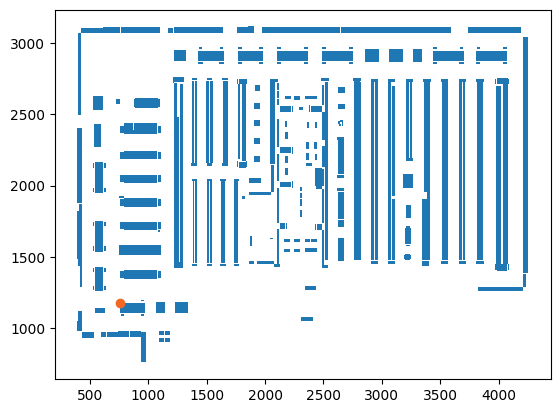

In [27]:
fig, ax = plt.subplots()
ax.plot()
for x, y, x1, y1 in zip(fixtures_df["STARTING_X"], fixtures_df["STARTING_Y"], fixtures_df["ENDING_X"], fixtures_df["ENDING_Y"]):
    ax.add_patch(Rectangle((x, y), float(x1-x), float(y1-y)))

items_subset_df = item_fixtures_df[item_fixtures_df["ARTICLE_ID_UOM"] == "20249840_EA"]

plt.plot(items_subset_df["X1"], items_subset_df["Y1"], 'o', color='#f16824')

plt.show()